#First

In [ ]:
import pandas as pd

# Load the train and test files
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

# Look at the first 5 rows of your training data
print(train.head())

# Check how much data you have
print(f"\nTraining set size: {len(train)} rows")


Here is a peek at your training data:
   Class Index                                              Title  \
0            3  Wall St. Bears Claw Back Into the Black (Reuters)   
1            3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2            3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3            3  Iraq Halts Oil Exports from Main Southern Pipe...   
4            3  Oil prices soar to all-time record, posing new...   

                                         Description  
0  Reuters - Short-sellers, Wall Street's dwindli...  
1  Reuters - Private investment firm Carlyle Grou...  
2  Reuters - Soaring crude prices plus worries\ab...  
3  Reuters - Authorities have halted oil export\f...  
4  AFP - Tearaway world oil prices, toppling reco...  

Training set size: 120000 rows


In [ ]:
# Combine Title and Description into a single 'text' column
train["text"] = train["Title"] + " " + train["Description"]
test["text"] = test["Title"] + " " + test["Description"]

# Keep only the columns we need (the label and the combined text)
train = train[["Class Index", "text"]]
test = test[["Class Index", "text"]]

# shuffle the data so there isn't any bias (didn't cause any changes)
train = train.sample(frac=1, random_state=42).reset_index(drop=True)
test = test.sample(frac=1, random_state=42).reset_index(drop=True)

# Check the first few rows
print(train.head())


   Class Index                                               text
0            3  BBC set for major shake-up, claims newspaper L...
1            3  Marsh averts cash crunch Embattled insurance b...
2            2  Jeter, Yankees Look to Take Control (AP) AP - ...
3            4  Flying the Sun to Safety When the Genesis caps...
4            3  Stocks Seen Flat as Nortel and Oil Weigh  NEW ...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

# 1. Create the pipeline
# TFIDF (Translator) -> SVM (Sorter)
model = Pipeline(
    [
        ("tfidf", TfidfVectorizer(stop_words="english", max_features=10000)),
        ("clf", LinearSVC()),
    ]
)

# 2. Train the model
print("Training the model...")
model.fit(train["text"], train["Class Index"])
print("Training complete!")

# 3. Test the model
print("\nEvaluating on test set...")
predictions = model.predict(test["text"])
print(classification_report(test["Class Index"], predictions))


Training the model...
Training complete!

Evaluating on test set...
              precision    recall  f1-score   support

           1       0.93      0.90      0.91      1900
           2       0.95      0.98      0.97      1900
           3       0.88      0.87      0.88      1900
           4       0.88      0.89      0.89      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



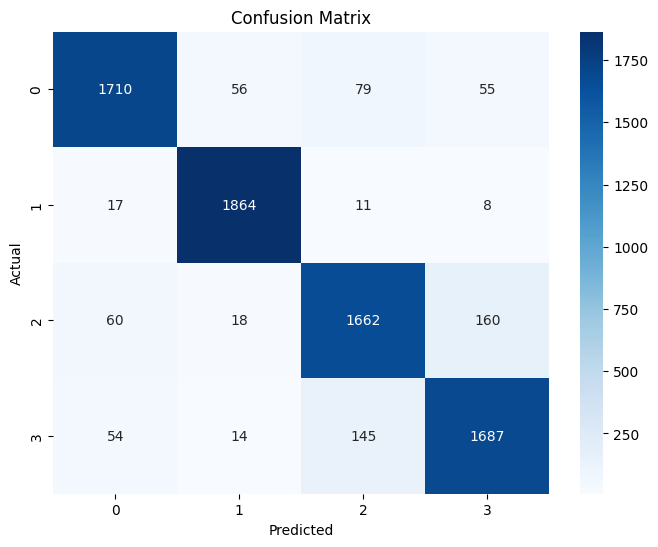

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix to find what confused the model
cm = confusion_matrix(test["Class Index"], predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
